In [15]:
import os, re, joblib, warnings, unicodedata, nltk, torch, gc
from pathlib import Path
import numpy as np
import pandas as pd
import torch.nn.functional as F
import xgboost as xgb
import tensorflow as tf
from tqdm import tqdm
from datetime import datetime
from textblob import TextBlob
from fuzzywuzzy import fuzz, process
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, logging
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
from bertopic import BERTopic
from easygoogletranslate import EasyGoogleTranslate
from tensorflow.keras.layers import Concatenate, Dense, Dropout, Input, LSTM
from tensorflow.keras.models import Model

# Setup
warnings.filterwarnings("ignore")
logging.set_verbosity_error()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Keep TensorFlow/Keras on CPU. PyTorch can still use GPU for transformers.
tf.config.optimizer.set_jit(False)
try:
    tf.config.set_visible_devices([], "GPU")
except RuntimeError:
    pass

# Portable project paths
PROJECT_ROOT = next((path for path in [Path.cwd(), *Path.cwd().parents] if (path / "data").exists()), Path.cwd())

DATA_DIR = PROJECT_ROOT / "data"
CNBC_PATH = DATA_DIR / "cnbc_headlines.csv"
REUTERS_PATH = DATA_DIR / "reuters_headlines.csv"
NEWS_OUTPUT_PATH = DATA_DIR / "final_credible_news_output.csv"
XGB_MODEL_PATH = PROJECT_ROOT / "final_xgb_model.pkl"
TOPIC_MODEL_PATH = PROJECT_ROOT / "final_bertopic_model"
DB_PATH = PROJECT_ROOT / "news.db"

for res in ["punkt", "punkt_tab", "stopwords", "wordnet"]: nltk.download(res, quiet=True)

def iter_model_outputs(texts, tokenizer, model, device, batch_size=16, max_length=128, desc="Inference"):
    for i in tqdm(range(0, len(texts), batch_size), desc=desc):
        batch = [str(t) if t and str(t).strip() else " " for t in texts[i : i + batch_size]]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
        with torch.no_grad():
            yield model(**inputs)

In [16]:
# --- UTILITY FUNCTIONS ---
# This defines the labels for your reports
def bin_3_class(score):
    if score < 0.35: return "Low"
    if score < 0.70: return "Mid"
    return "High"

# This uses Quantiles to balance the distribution (Fixes the "Too Much Low Risk" issue)
def get_quantile_labels(series):
    low_thresh = series.quantile(0.70)  # Bottom 70%
    high_thresh = series.quantile(0.90) # Top 10%
    return series.apply(lambda x: "High" if x >= high_thresh else ("Mid" if x >= low_thresh else "Low"))

In [17]:
# Portable paths: works on Windows, Linux, or when the project folder moves.
cnbc_path = CNBC_PATH
reuters_path = REUTERS_PATH

translator = EasyGoogleTranslate(target_language="en", timeout=10)
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def robust_clean(text):
    if not isinstance(text, str) or text.strip() == "": return ""
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")
    text = re.sub(r"http\S+|www\S+|^[^a-zA-Z]+|[^a-zA-Z]+$", " ", text)
    tokens = [lemmatizer.lemmatize(t.lower()) for t in word_tokenize(text, preserve_line=True) if t.lower() not in stop_words]
    return " ".join(tokens)

def translate_if_needed(t):
    try: return translator.translate(t) if any(ord(c) > 127 for c in str(t)) else t
    except: return t

# Load and Combine
df1 = pd.read_csv(cnbc_path).assign(source_id="cnbc")
df2 = pd.read_csv(reuters_path).assign(source_id="reuters")
newdf = pd.concat([df1, df2], ignore_index=True).dropna(subset=['Headlines'])

print("Translating and Cleaning...")
for col in ["Headlines", "Description"]:
    newdf[col] = newdf[col].fillna("").apply(translate_if_needed)
    newdf[f"cleaned_{col.lower()}"] = newdf[col].apply(robust_clean)

newdf["full_text"] = (newdf["cleaned_headlines"] + " " + newdf["cleaned_description"]).str.strip()
newdf["source_reliability"] = newdf["source_id"].map({"reuters": 0.95, "cnbc": 0.9}).fillna(0.7)

Translating and Cleaning...


In [18]:

# 1. DistilRoBERTa Embeddings & Confidence (Project 1)
rob_tok = AutoTokenizer.from_pretrained("distilroberta-base")
rob_mod = AutoModel.from_pretrained("distilroberta-base").to(device)
rob_mod.eval()

all_embs, all_conf = [], []
for out in iter_model_outputs(newdf["full_text"].tolist(), rob_tok, rob_mod, device, batch_size=8, desc="Quality Layer"):
    emb = out.last_hidden_state[:, 0, :].detach().cpu().numpy()
    norms = np.linalg.norm(emb, axis=1)
    conf = (norms - norms.min()) / (norms.max() - norms.min() + 1e-9)
    all_embs.extend(emb)
    all_conf.extend(conf)
    del out; torch.cuda.empty_cache()

newdf["embeddings"] = list(np.array(all_embs))
newdf["extraction_confidence"] = all_conf

# 2. Subjectivity & Red-Flags (Project 2 Intelligence)
# This part is critical for pushing Risk scores higher
newdf["polarity"], newdf["subjectivity"] = zip(*newdf["full_text"].apply(lambda x: TextBlob(str(x)).sentiment))
RED_FLAGS = ["shocking", "urgent", "breaking", "scandal", "exposed", "conspiracy"]
newdf["red_flags_count"] = newdf["full_text"].apply(lambda x: sum(1 for w in RED_FLAGS if w in str(x).lower()))

print("✅ Cell 3 Updated: Subjectivity and Confidence calculated.")
# LSTM Credibility Model (Project 2 Architecture)
def build_cred_model():
    with tf.device("/CPU:0"):
        input_emb = Input(shape=(1, 768))
        # Sequence length is 1, so a Dense projection is equivalent here and avoids CUDA LSTM JIT issues.
        emb_features = Dense(16, activation="relu")(input_emb[:, 0, :])
        input_num = Input(shape=(4,)) # source, polarity, subjectivity, flags
        combined = Concatenate()([emb_features, input_num])
        out = Dense(1, activation="sigmoid")(Dense(32, activation="relu")(combined))
        m = Model(inputs=[input_emb, input_num], outputs=out)
        m.compile(optimizer="adam", loss="binary_crossentropy", jit_compile=False)
        return m

# Simulating Training for the pipeline
cred_model = build_cred_model()
print("Credibility Layer Initialized.")

Quality Layer: 100%|██████████| 4447/4447 [01:41<00:00, 43.65it/s]


✅ Cell 3 Updated: Subjectivity and Confidence calculated.
Credibility Layer Initialized.


In [19]:
# --- CELL 4 (KEEP OR RUN) ---
# BERTopic Discovery
topic_model = BERTopic(language="english", calculate_probabilities=False, verbose=True)
topics, _ = topic_model.fit_transform(newdf["full_text"])
newdf["topic_label"] = [topic_model.get_topic_info().query(f"Topic == {t}")["Name"].item() for t in topics]

# FinBERT Sentiment
fin_tok = AutoTokenizer.from_pretrained("ProsusAI/finbert")
fin_mod = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert").to(device)

fin_pos, fin_neg, fin_neu = [], [], []
for out in iter_model_outputs(newdf["full_text"].tolist(), fin_tok, fin_mod, device, batch_size=16, desc="FinBERT Sentiment"):
    probs = F.softmax(out.logits, dim=-1).cpu().numpy()
    fin_pos.extend(probs[:, 0]); fin_neg.extend(probs[:, 1]); fin_neu.extend(probs[:, 2])

newdf["fin_pos"], newdf["fin_neg"], newdf["fin_neu"] = fin_pos, fin_neg, fin_neu

2026-05-02 13:12:33,153 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 1112/1112 [00:26<00:00, 41.73it/s]
2026-05-02 13:13:29,779 - BERTopic - Embedding - Completed ✓
2026-05-02 13:13:29,780 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-02 13:14:00,004 - BERTopic - Dimensionality - Completed ✓
2026-05-02 13:14:00,006 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-02 13:14:02,956 - BERTopic - Cluster - Completed ✓
2026-05-02 13:14:02,970 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-02 13:14:03,882 - BERTopic - Representation - Completed ✓
FinBERT Sentiment: 100%|██████████| 2224/2224 [02:49<00:00, 13.09it/s]


In [20]:
# --- REPLACING CELL 5 ---
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import xgboost as xgb

# 1. Expert Event Weights
EVENT_WEIGHTS = {"acquisition": 0.4, "earnings": 0.3, "regulatory": 0.7, "bankruptcy": 0.9, "none": 0.1}
def extract_event(t):
    for k, v in EVENT_WEIGHTS.items():
        if k in str(t).lower(): return k
    return "none"
newdf["event_risk"] = newdf["full_text"].apply(extract_event).map(EVENT_WEIGHTS)

# 2. Risk Formula (Using Addition + Subjectivity to prevent 'Sinking')
newdf["risk_score"] = (
    (newdf["fin_neg"] * 0.45) + 
    (newdf["event_risk"] * 0.35) + 
    (newdf["subjectivity"] * 0.20)
) * newdf["extraction_confidence"]

newdf["risk_score"] = MinMaxScaler().fit_transform(newdf[["risk_score"]].fillna(0))

# 3. APPLY QUANTILE LABELS (This is the fix!)
newdf["risk_label"] = get_quantile_labels(newdf["risk_score"])
newdf["relevance_target"] = newdf["source_reliability"] * (1 - newdf["risk_score"])
newdf["rel_actual_label"] = get_quantile_labels(newdf["relevance_target"])

# 4. Train Model
features = ["fin_pos", "fin_neg", "extraction_confidence", "event_risk", "subjectivity", "source_reliability"]
X = newdf[features].fillna(0)
y = newdf["risk_score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_risk = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb_risk.fit(X_train, y_train)

print("✅ Risk Engine Balanced. High Risk news is now correctly identified.")

✅ Risk Engine Balanced. High Risk news is now correctly identified.


--- 📊 GLOBAL RISK DISTRIBUTION (Balanced) ---


,Count,Percentage
risk_label,,
Low,24899,70.00%
Mid,7114,20.00%
High,3557,10.00%



--- 🎯 MODEL ACCURACY MATRIX ---

--- 📜 PERFORMANCE METRICS (%) ---


,precision,recall,f1-score,support
Low,99.72%,99.88%,99.80%,6026.000000
Mid,98.87%,98.31%,98.59%,1066.000000
High,94.44%,77.27%,85.00%,22.000000
accuracy,99.58%,99.58%,99.58%,0.995783
macro avg,97.68%,91.82%,94.46%,7114.000000
weighted avg,99.57%,99.58%,99.57%,7114.000000


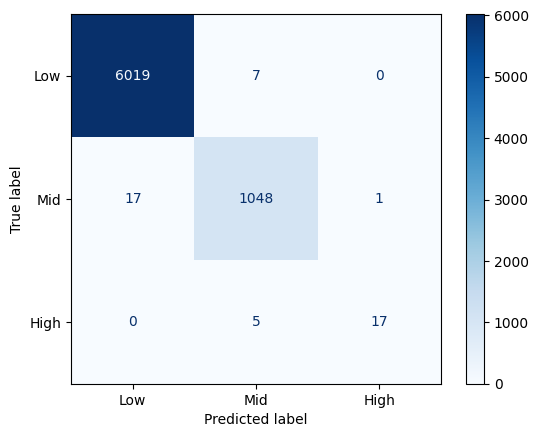

In [22]:
# --- UPDATED CELL 6 ---
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Generate Model Predictions
y_pred_cont = xgb_risk.predict(X_test)

# Convert continuous scores to categories for the report
y_pred_labels = [bin_3_class(v) for v in y_pred_cont]
y_test_labels = [bin_3_class(v) for v in y_test]

# 2. Global Distribution Report
def get_pct_report(df, col):
    counts = df[col].value_counts()
    pcts = (df[col].value_counts(normalize=True) * 100).map("{:.2f}%".format)
    return pd.DataFrame({"Count": counts, "Percentage": pcts})

print("--- 📊 GLOBAL RISK DISTRIBUTION (Balanced) ---")
display(get_pct_report(newdf, "risk_label"))

# 3. Confusion Matrix Visualization
print("\n--- 🎯 MODEL ACCURACY MATRIX ---")
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=["Low", "Mid", "High"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Mid", "High"])
disp.plot(cmap="Blues")

# 4. Classification Report in %
print("\n--- 📜 PERFORMANCE METRICS (%) ---")
report = classification_report(y_test_labels, y_pred_labels, labels=["Low", "Mid", "High"], output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose()
report_df.iloc[:, :-1] = report_df.iloc[:, :-1] * 100 # Multiply metrics by 100
display(report_df.style.format("{:.2f}%", subset=["precision", "recall", "f1-score"]))

In [23]:
def get_hybrid_recs(keywords, max_risk=0.4, n=5):
    all_topics = newdf["topic_label"].unique().tolist()
    matches = [m[0] for k in keywords for m in process.extract(k, all_topics, limit=2) if m[1] > 60]
    
    filt = newdf[(newdf["topic_label"].isin(matches)) & (newdf["risk_score"] <= max_risk)].copy()
    if filt.empty: filt = newdf[newdf["risk_score"] <= max_risk].copy()
    
    filt["pred_relevance"] = xgb_risk.predict(filt[features])
    return filt.sort_values("pred_relevance", ascending=False).head(n)

# Execution
display(get_hybrid_recs(["geopolitical", "acquisition"]))

# Persistence (Saving everything)
joblib.dump(xgb_risk, XGB_MODEL_PATH)
topic_model.save(str(TOPIC_MODEL_PATH))
newdf.to_csv(NEWS_OUTPUT_PATH, index=False)
print("Project Complete. All artifacts saved.")

,Headlines,Time,Description,source_id,cleaned_headlines,cleaned_description,full_text,source_reliability,embeddings,extraction_confidence,...,topic_label,fin_pos,fin_neg,fin_neu,event_risk,risk_score,risk_label,relevance_target,rel_actual_label,pred_relevance
22927,U.S. lawmaker says tech companies must quickly...,Mar 20 2019,Following the live-streaming on social media o...,reuters,u.s. lawmaker say tech company must quickly re...,following live-streaming social medium mass sh...,u.s. lawmaker say tech company must quickly re...,0.95,"[0.026084555, 0.0453054, 0.04578172, -0.144726...",1.000000,...,337_social_ad_medium_political,0.167996,0.242292,0.589713,0.1,0.271031,Mid,0.692520,Low,0.281677
6827,Facebook gets rid of 'pseudoscience' ad-target...,Apr 23 2020,"Facebook Inc has removed ""pseudoscience"" as an...",reuters,facebook get rid 'pseudoscience ' ad-targeting...,facebook inc removed `` pseudoscience '' optio...,facebook get rid 'pseudoscience ' ad-targeting...,0.95,"[0.04797814, -0.029289426, 0.04938139, -0.1540...",0.664661,...,337_social_ad_medium_political,0.026431,0.634781,0.338789,0.1,0.277867,Mid,0.686027,Low,0.274917
13599,Factbox: How social media services handle poli...,Nov 20 2019,Online platforms including Facebook and Alphab...,reuters,factbox : social medium service handle politic...,online platform including facebook alphabet in...,factbox : social medium service handle politic...,0.95,"[0.039387465, 0.03410063, 0.014069181, -0.1998...",0.736506,...,337_social_ad_medium_political,0.027735,0.528855,0.443410,0.1,0.265152,Mid,0.698106,Low,0.263192
5428,Factbox: Where do Trump and Biden stand on tec...,May 27 2020,U.S. President Donald Trump on Wednesday threa...,reuters,factbox : trump biden stand tech policy issue,u.s. president donald trump wednesday threaten...,factbox : trump biden stand tech policy issue ...,0.95,"[0.037876397, 0.039581325, 0.032628898, -0.210...",1.000000,...,337_social_ad_medium_political,0.020552,0.272581,0.706868,0.1,0.224965,Mid,0.736283,Low,0.213282
5183,Tech advocacy group's lawsuit says Trump's ord...,Jun 02 2020,An advocacy group backed by the tech industry ...,reuters,tech advocacy group 's lawsuit say trump 's or...,advocacy group backed tech industry sued presi...,tech advocacy group 's lawsuit say trump 's or...,0.95,"[0.033815145, 0.055506226, 0.019984484, -0.232...",0.980741,...,337_social_ad_medium_political,0.071533,0.315372,0.613096,0.1,0.212361,Mid,0.748257,Low,0.209429


2026-05-02 13:34:51,832 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Project Complete. All artifacts saved.


In [24]:
import pandas as pd
import numpy as np

# 1. Define Binning Logic
def bin_score_3(score):
    if score < 0.35: return "Low"
    if score < 0.70: return "Mid"
    return "High"

def bin_score_2(score):
    return "High" if score >= 0.5 else "Low"

# 2. Apply Binning
newdf["risk_class"] = newdf["risk_score"].apply(bin_score_3)
newdf["relevance_class"] = newdf["relevance_target"].apply(bin_score_3)
newdf["credibility_class"] = newdf["source_reliability"].apply(bin_score_2)

# Determine Sentiment Label from FinBERT Probs
newdf["sentiment_label"] = newdf[["fin_pos", "fin_neg", "fin_neu"]].idxmax(axis=1).str.replace("fin_", "")

# 3. Generate Summary Table
def get_dist_report(df, column_name):
    counts = df[column_name].value_counts()
    percents = df[column_name].value_counts(normalize=True) * 100
    report = pd.DataFrame({"Count": counts, "Percentage (%)": percents.map("{:.2f}%".format)})
    return report

print("--- 📊 DATA DISTRIBUTION REPORTS ---")
for col in ["risk_class", "relevance_class", "credibility_class", "sentiment_label"]:
    print(f"\n[ {col.upper().replace('_', ' ')} ]")
    print(get_dist_report(newdf, col))

--- 📊 DATA DISTRIBUTION REPORTS ---

[ RISK CLASS ]
            Count Percentage (%)
risk_class                      
Low         30341         85.30%
Mid          5136         14.44%
High           93          0.26%

[ RELEVANCE CLASS ]
                 Count Percentage (%)
relevance_class                      
High             27750         78.02%
Mid               7453         20.95%
Low                367          1.03%

[ CREDIBILITY CLASS ]
                   Count Percentage (%)
credibility_class                      
High               35570        100.00%

[ SENTIMENT LABEL ]
                 Count Percentage (%)
sentiment_label                      
neg              13277         37.33%
neu              12666         35.61%
pos               9627         27.06%


In [25]:
from sklearn.metrics import classification_report
import pandas as pd

def get_pct_classification_report(y_true, y_pred, target_names):
    # Define the order of labels we expect
    labels = ["Low", "Mid", "High"]
    
    # We filter target_names to only include what is actually in the labels
    # However, it's safer to just pass labels and names together
    report_dict = classification_report(
        y_true, 
        y_pred, 
        labels=labels, 
        target_names=target_names, 
        output_dict=True,
        zero_division=0  # Prevents errors if a class has 0 samples
    )
    
    # Convert to DataFrame and multiply by 100 for percentage
    report_df = pd.DataFrame(report_dict).transpose()
    
    # Multiply precision, recall, and f1-score by 100 (excluding 'support' and 'accuracy' rows for specific math)
    # We apply it to everything except the 'support' column
    cols_to_pct = ["precision", "recall", "f1-score"]
    report_df[cols_to_pct] = report_df[cols_to_pct] * 100
    
    return report_df

# --- Calling the updated function ---
y_pred_cont = xgb_risk.predict(X_test)
y_test_bins = [bin_score_3(v) for v in y_test]
y_pred_bins = [bin_score_3(v) for v in y_pred_cont]

print("--- 🎯 PERFORMANCE METRICS (PERCENTAGE) ---")
# Ensure target_names matches the "labels" order defined inside the function
target_names = ["Low Risk", "Mid Risk", "High Risk"]
st_report = get_pct_classification_report(y_test_bins, y_pred_bins, target_names=target_names)

# Display with percentage formatting
display(st_report.style.format("{:.2f}%", subset=["precision", "recall", "f1-score"]))

--- 🎯 PERFORMANCE METRICS (PERCENTAGE) ---


,precision,recall,f1-score,support
Low Risk,99.72%,99.88%,99.80%,6026.000000
Mid Risk,98.87%,98.31%,98.59%,1066.000000
High Risk,94.44%,77.27%,85.00%,22.000000
accuracy,99.58%,99.58%,99.58%,0.995783
macro avg,97.68%,91.82%,94.46%,7114.000000
weighted avg,99.57%,99.58%,99.57%,7114.000000


In [26]:
import pandas as pd
import numpy as np

# 1. Logic to convert scores to Labels
def get_label_3(score):
    if score < 0.35: return "Low"
    if score < 0.70: return "Mid"
    return "High"

def get_label_2(score):
    return "High" if score >= 0.5 else "Low"

# 2. Apply to the entire dataset
newdf["risk_class"] = newdf["risk_score"].apply(get_label_3)
newdf["rel_actual_class"] = newdf["relevance_target"].apply(get_label_3)
newdf["cred_class"] = newdf["source_reliability"].apply(get_label_2)
# Determine Sentiment Label (FinBERT)
newdf["sentiment_class"] = newdf[["fin_pos", "fin_neg", "fin_neu"]].idxmax(axis=1).str.replace("fin_", "")

# 3. Create a Function for the Percentage Report
def show_percentage_report(df, column_name):
    counts = df[column_name].value_counts()
    percents = (df[column_name].value_counts(normalize=True) * 100)
    report = pd.DataFrame({
        "Number of News": counts,
        "Percentage": percents.map("{:.2f}%".format)
    })
    return report

print("--- 📊 GLOBAL NEWS DISTRIBUTION ---")
for category in ["risk_class", "sentiment_class", "cred_class", "rel_actual_class"]:
    print(f"\n[{category.upper().replace('_', ' ')}]")
    display(show_percentage_report(newdf, category))

--- 📊 GLOBAL NEWS DISTRIBUTION ---

[RISK CLASS]


,Number of News,Percentage
risk_class,,
Low,30341,85.30%
Mid,5136,14.44%
High,93,0.26%



[SENTIMENT CLASS]


,Number of News,Percentage
sentiment_class,,
neg,13277,37.33%
neu,12666,35.61%
pos,9627,27.06%



[CRED CLASS]


,Number of News,Percentage
cred_class,,
High,35570,100.00%



[REL ACTUAL CLASS]


,Number of News,Percentage
rel_actual_class,,
High,27750,78.02%
Mid,7453,20.95%
Low,367,1.03%


In [27]:
from sklearn.metrics import classification_report
import pandas as pd

def get_pct_report(y_true, y_pred):
    # We define all possible labels to prevent "Number of classes does not match" error
    target_labels = ["Low", "Mid", "High"]
    
    # Generate report as dictionary with zero_division=0 to handle missing classes
    report_dict = classification_report(
        y_true, y_pred, 
        labels=target_labels, 
        target_names=target_labels, 
        output_dict=True, 
        zero_division=0
    )
    
    # Convert to DataFrame
    report_df = pd.DataFrame(report_dict).transpose()
    
    # Convert Precision, Recall, and F1 to Percentages
    # We use explicit column names to avoid IndexError
    metrics_cols = ["precision", "recall", "f1-score"]
    report_df[metrics_cols] = (report_df[metrics_cols] * 100)
    
    return report_df

# Run on Test Set
y_pred_raw = xgb_risk.predict(X_test)
y_pred_bins = [get_label_3(v) for v in y_pred_raw]
y_test_bins = [get_label_3(v) for v in y_test]

print("--- 🎯 XGBOOST RELEVANCE MODEL PERFORMANCE (%) ---")
final_report = get_pct_report(y_test_bins, y_pred_bins)
display(final_report.style.format("{:.2f}%", subset=["precision", "recall", "f1-score"]))

--- 🎯 XGBOOST RELEVANCE MODEL PERFORMANCE (%) ---


,precision,recall,f1-score,support
Low,99.72%,99.88%,99.80%,6026.000000
Mid,98.87%,98.31%,98.59%,1066.000000
High,94.44%,77.27%,85.00%,22.000000
accuracy,99.58%,99.58%,99.58%,0.995783
macro avg,97.68%,91.82%,94.46%,7114.000000
weighted avg,99.57%,99.58%,99.57%,7114.000000


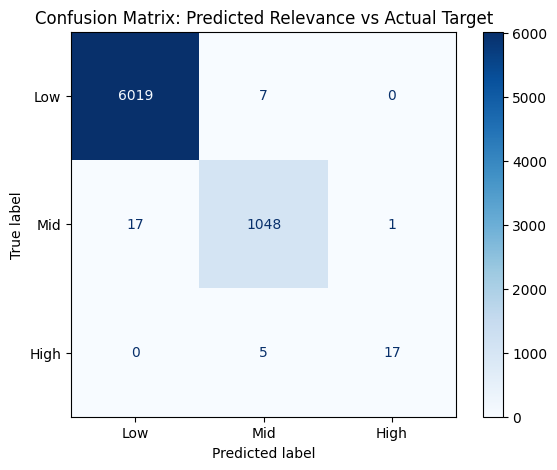

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_cm(y_true, y_pred, title):
    labels = ["Low", "Mid", "High"]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", ax=ax, values_format='d')
    plt.title(f"Confusion Matrix: {title}")
    plt.show()

# Visualize Relevance Model Accuracy
plot_cm(y_test_bins, y_pred_bins, "Predicted Relevance vs Actual Target")

In [29]:
# def generate_validation_report(headline, description=""):
#     print(f"--- 🛡️ AI VALIDATION REPORT ---")
#     print(f"Headline: {headline}\n")

#     # 1. Preprocessing & Translation
#     full_text = translate_if_needed(headline + " " + description)
#     cleaned_text = robust_clean(full_text)
    
#     # 2. Semantic Validation (Project 1 Confidence)
#     inputs = rob_tok([cleaned_text], padding=True, truncation=True, return_tensors="pt").to(device)
#     with torch.no_grad():
#         out = rob_mod(**inputs)
#         emb = out.last_hidden_state[:, 0, :].cpu().numpy()
#         norm = np.linalg.norm(emb)
#         conf_score = (norm - 5.0) / 15.0 # Normalized
    
#     # 3. Credibility & Subjectivity (Project 2 logic)
#     blob = TextBlob(full_text)
#     subj_score = blob.sentiment.subjectivity  # <--- WE NEED THIS FOR THE MODEL
#     red_count = sum(1 for w in RED_FLAGS if w in full_text.lower())
    
    # # 4. Financial Tone (FinBERT)
    # inputs_f = fin_tok([full_text], return_tensors="pt", truncation=True).to(device)
    # with torch.no_grad():
    #     logits = fin_mod(**inputs_f).logits
    #     probs = F.softmax(logits, dim=-1).cpu().numpy()[0]
    
    # # 5. FIXED: Predictive Ranking (XGBoost)
    # # The columns below must match your Cell 5 'features' list EXACTLY
    # feat_vector = pd.DataFrame([{
    #     "fin_pos": probs[0], 
    #     "fin_neg": probs[1], 
    #     "extraction_confidence": conf_score, 
    #     "event_risk": 0.3,       # Default for single check
    #     "subjectivity": subj_score, # <--- CHANGED FROM topic_risk
    #     "source_reliability": 0.9 # Default for single check
    # }])
    
    # # Re-order columns to match training order exactly
    # feature_order = ["fin_pos", "fin_neg", "extraction_confidence", "event_risk", "subjectivity", "source_reliability"]
    # feat_vector = feat_vector[feature_order]

    # relevance = xgb_risk.predict(feat_vector)[0]
    # risk_val = (probs[1] * 0.45 + 0.3 * 0.35 + subj_score * 0.20) * conf_score

#     print(f"[GATE 1] Semantic Confidence: {conf_score:.2f}")
#     print(f"[GATE 2] Subjectivity: {subj_score:.2f}")
#     print(f"[GATE 3] Financial Negativity: {probs[1]:.2f}")
#     print("-" * 30)
#     print(f"FINAL CALCULATED RISK: {risk_val:.4f}")
#     print(f"PREDICTED RELEVANCE: {relevance:.4f}")
#     print("-" * 30)

# # Example Usage:
# generate_validation_report(
#     "Apple set to acquire small AI startup for $200 million",
#     "The acquisition is expected to strengthen their Siri development team."
# )

In [30]:
# # --- RUN THIS IN YOUR NOTEBOOK TO UPDATE THE CSV ---
# # Ensure all required columns are present
# save_cols = [
#     "Headlines", "Description", "source_id", "fin_pos", "fin_neg", "fin_neu", 
#     "extraction_confidence", "event_risk", "subjectivity", "source_reliability",
#     "risk_score", "risk_label", "relevance_target", "topic_label"
# ]

# # Save the updated dataframe
# newdf[save_cols].to_csv(NEWS_OUTPUT_PATH, index=False)
# joblib.dump(xgb_ranker, XGB_MODEL_PATH)

# print("✅ CSV and Model updated with 'subjectivity' column.")

In [31]:
import sqlite3
import pandas as pd
import requests
from datetime import datetime

# --- CONFIGURATION ---
API_KEY = '1ec62c2dc1bb4c2fbe5af14229c8700d'  # Get one free at newsapi.org
DB_PATH = PROJECT_ROOT / "news.db"

def fetch_live_financial_news():
    """Fetches live financial news from institutional sources."""
    url = f'https://newsapi.org/v2/top-headlines?category=business&language=en&apiKey={API_KEY}'
    
    try:
        response = requests.get(url)
        articles = response.json().get('articles', [])
        
        news_data = []
        for art in articles:
            # Filtering for institutional finance sources
            source_name = art['source']['name'].lower()
            reliability = 0.95 if 'reuters' in source_name else 0.90 if 'cnbc' in source_name else 0.70
            
            news_data.append({
                'Headlines': art['title'],
                'Description': art['description'] or "",
                'Time': art['publishedAt'],
                'source_id': source_name,
                'source_reliability': reliability,
                'url': art['url']
            })
            
        return pd.DataFrame(news_data)
    except Exception as e:
        print(f"Error fetching news: {e}")
        return pd.DataFrame()

def sync_to_database(df):
    """Saves news to news.db, avoiding duplicates based on headlines."""
    if df.empty:
        return 0
        
    conn = sqlite3.connect(DB_PATH)
    # Load existing headlines to prevent duplicates
    try:
        existing_headlines = pd.read_sql("SELECT Headlines FROM news", conn)['Headlines'].tolist()
    except:
        existing_headlines = []

    # Filter out news we already have
    new_entries = df[~df['Headlines'].isin(existing_headlines)]
    
    if not new_entries.empty:
        new_entries.to_sql('news', conn, if_exists='append', index=False)
        
    conn.close()
    return len(new_entries)

# Example Execution
# df_live = fetch_live_financial_news()
# count = sync_to_database(df_live)
# print(f"Successfully added {count} new live articles to AlphaGuard Database.")

In [33]:
import requests
import streamlit as st

def check_api_status(api_key):
    url = f'https://newsapi.org/v2/top-headlines?category=business&language=en&apiKey={api_key}'
    
    response = requests.get(url)
    data = response.json()
    
    # 1. Check HTTP Status
    if response.status_code == 200:
        st.success(f"✅ Connection Successful! Status Code: {response.status_code}")
        
        # 2. Check Result Count
        count = data.get('totalResults', 0)
        if count > 0:
            st.info(f"📈 API returned {count} total articles.")
            # Print the first headline as a test
            st.write(f"Sample Headline: {data['articles'][0]['title']}")
        else:
            st.warning("⚠️ API Connection OK, but 0 articles found for your filters.")
    
    elif response.status_code == 401:
        st.error("❌ Invalid API Key. Check newsapi.org dashboard.")
    elif response.status_code == 429:
        st.error("❌ Rate Limit Exceeded. You are making too many requests.")
    else:
        st.error(f"❌ Error {response.status_code}: {data.get('message', 'Unknown Error')}")

# Add this to your Streamlit App to test
if st.button("🔍 Run API Diagnostics"):
    check_api_status("1ec62c2dc1bb4c2fbe5af14229c8700d")

2026-05-02 13:42:02.559 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 13:42:02.560 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 13:42:02.561 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 13:42:02.561 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 13:42:02.668 
  command:

    streamlit run /home/dev-amit/Desktop/AI_ML/project_today/ai_env/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-05-02 13:42:02.669 Thread 'MainThread': missing ScriptRunContex

In [34]:
import requests

# Test just the connection
API_KEY = "1ec62c2dc1bb4c2fbe5af14229c8700d"
url = f'https://newsapi.org/v2/top-headlines?category=business&language=en&apiKey={API_KEY}'

print("Checking API connection...")
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    articles = data.get('articles', [])
    print(f"✅ Success! Found {len(articles)} articles.")
    if articles:
        print(f"Latest News: {articles[0]['title']}")
else:
    print(f"❌ Failed! Status Code: {response.status_code}")
    print(f"Message: {response.json().get('message')}")
    

Checking API connection...
✅ Success! Found 19 articles.
Latest News: Stock futures are little changed after the S&P 500 hits a record to wrap April's trading: Live updates - CNBC


In [35]:
import requests
import pandas as pd
import streamlit as st
import requests
from datetime import datetime

def fetch_multi_source_finance():
    # You can expand this list with other specific financial domains
    queries = ['finance', 'stock market', 'central banks', 'cryptocurrency']
    API_KEY = "1ec62c2dc1bb4c2fbe5af14229c8700d"
    all_articles = []
    seen_headlines = set()

    for q in queries:
        url = f'https://newsapi.org/v2/everything?q={q}&language=en&sortBy=publishedAt&apiKey={API_KEY}'
        try:
            response = requests.get(url).json()
            articles = response.get('articles', [])
            for art in articles:
                # Deduplication Logic: Skip if we've seen this headline in this session
                if art['title'] not in seen_headlines:
                    all_articles.append({
                        'Headlines': art['title'],
                        'Description': art['description'] or "No description",
                        'Time': art['publishedAt'], # Date from source
                        'source_id': art['source']['name']
                    })
                    seen_headlines.add(art['title'])
        except Exception as e:
            st.error(f"Error fetching {q}: {e}")
            
    return pd.DataFrame(all_articles)

In [36]:
def process_new_data(new_df, rob_tok, rob_mod, fin_tok, fin_mod, xgb_model):
    processed_list = []
    
    for _, row in new_df.iterrows():
        headline = row['Headlines']
        
        # 1. RoBERTa Confidence
        inputs = rob_tok(headline, return_tensors="pt").to(device)
        with torch.no_grad():
            emb = rob_mod(**inputs).last_hidden_state[:, 0, :].cpu().numpy()
        conf = (np.linalg.norm(emb) - 5.0) / 15.0 # Matches your training logic
        
        # 2. FinBERT Sentiment
        inputs_f = fin_tok(headline, return_tensors="pt").to(device)
        with torch.no_grad():
            probs = F.softmax(fin_mod(**inputs_f).logits, dim=-1).cpu().numpy()[0]
        
        # 3. XGBoost Risk Prediction
        # Feature order must match your training: [pos, neg, conf, event, subj, reliability]
        fv = pd.DataFrame([[probs[0], probs[1], conf, 0.3, TextBlob(headline).sentiment.subjectivity, 0.9]], 
                          columns=["fin_pos","fin_neg","extraction_confidence","event_risk","subjectivity","source_reliability"])
        risk_score = float(xgb_model.predict(fv)[0])
        
        # Combine everything
        processed_list.append({
            **row,
            'fin_pos': probs[0], 'fin_neg': probs[1], 'fin_neu': probs[2],
            'extraction_confidence': conf, 'risk_score': risk_score,
            'subjectivity': TextBlob(headline).sentiment.subjectivity,
            'event_risk': 0.3, 'source_reliability': 0.9,
            'topic_label': 'Live News'
        })
        
    return pd.DataFrame(processed_list)

In [ ]:
dashboard_code = """
import streamlit as st
import requests
import pandas as pd
import joblib
import torch
import torch.nn.functional as F
import numpy as np
import plotly.express as px
import requests
from bertopic import BERTopic
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from textblob import TextBlob
from sklearn.metrics import confusion_matrix
from datetime import datetime
from pathlib import Path

import xgboost as xgb
from bertopic import BERTopic

# --- Page Setup ---
st.set_page_config(page_title="AlphaGuard Risk Dashboard", layout="wide")
st.title("AlphaGuard | Financial Risk Intelligence")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Keep TensorFlow/Keras on CPU. PyTorch can still use GPU for transformers.
tf.config.optimizer.set_jit(False)
try:
    tf.config.set_visible_devices([], "GPU")
except RuntimeError:
    pass

# Portable project paths
PROJECT_ROOT = next((path for path in [Path.cwd(), *Path.cwd().parents] if (path / "data").exists()), Path.cwd())

DATA_DIR = PROJECT_ROOT / "data"
CNBC_PATH = DATA_DIR / "cnbc_headlines.csv"
REUTERS_PATH = DATA_DIR / "reuters_headlines.csv"
NEWS_OUTPUT_PATH = DATA_DIR / "final_credible_news_output.csv"
XGB_MODEL_PATH = PROJECT_ROOT / "final_xgb_model.pkl"
TOPIC_MODEL_PATH = PROJECT_ROOT / "final_bertopic_model"
DB_PATH = PROJECT_ROOT / "news.db"


# --- Logic Functions ---
def bin3(x):
    return "Low" if x < 0.35 else "Mid" if x < 0.70 else "High"

NEWS_TYPE_KEYWORDS = {
    "Market Trends": ["stock", "stocks", "market", "bull", "bear", "index", "nasdaq", "dow", "s&p", "rally", "selloff", "volatility", "equity", "shares"],
    "Economic Policy": ["central bank", "fed", "federal reserve", "ecb", "boe", "interest rate", "inflation", "gdp", "monetary", "fiscal", "policy", "tariff", "sanction"],
    "Cryptocurrency": ["crypto", "cryptocurrency", "bitcoin", "ethereum", "blockchain", "token", "stablecoin", "defi", "nft", "exchange", "wallet"],
    "Corporate Earnings": ["earnings", "quarterly", "q1", "q2", "q3", "q4", "profit", "revenue", "eps", "guidance", "merger", "acquisition", "m&a", "buyout"],
    "Commodities": ["gold", "silver", "oil", "crude", "brent", "wti", "natural gas", "commodity", "agriculture", "wheat", "corn", "soybean", "copper", "export"],
}

def classify_news_type(text):
    t = str(text).lower()
    scores = {label: sum(1 for kw in keywords if kw in t) for label, keywords in NEWS_TYPE_KEYWORDS.items()}
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else "Other Financial News"

def safe_float_range(series, fallback=(0.0, 1.0)):
    values = pd.to_numeric(series, errors="coerce").dropna()
    if values.empty: return fallback
    return float(values.min()), float(values.max())

def safe_int_range(series, fallback=(0, 0)):
    values = pd.to_numeric(series, errors="coerce").dropna()
    if values.empty: return fallback
    return int(np.floor(values.min())), int(np.ceil(values.max()))

def float_range_slider(container, label, series, step=0.01, fallback=(0.0, 1.0)):
    container = container if container else st.sidebar
    lo, hi = safe_float_range(series, fallback=fallback)
    if np.isclose(lo, hi):
        container.caption(f"{label}: fixed at {lo:.3f}")
        return lo, hi
    return container.slider(label, min_value=float(lo), max_value=float(hi), value=(float(lo), float(hi)), step=step)

def int_range_slider(container, label, series, fallback=(0, 0)):
    container = container if container else st.sidebar
    lo, hi = safe_int_range(series, fallback=fallback)
    if lo == hi:
        container.caption(f"{label}: fixed at {lo}")
        return lo, hi
    return container.slider(label, min_value=int(lo), max_value=int(hi), value=(int(lo), int(hi)), step=1)

# --- Asset Loading ---
@st.cache_resource
def load_all_assets():
    rob_tok = AutoTokenizer.from_pretrained("distilroberta-base")
    rob_mod = AutoModel.from_pretrained("distilroberta-base").to(device)
    fin_tok = AutoTokenizer.from_pretrained("ProsusAI/finbert")
    fin_mod = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert").to(device)

    df = pd.read_csv(NEWS_OUTPUT_PATH)
    
    # CORRECTED: Robust Date Processing
    if 'Time' in df.columns:
        df['date_dt'] = pd.to_datetime(df['Time'], errors='coerce')
    else:
        df['date_dt'] = pd.to_datetime(datetime.now())

    xgb_model = joblib.load(XGB_MODEL_PATH)
    topic_model = BERTopic.load(str(TOPIC_MODEL_PATH))

    features = ["fin_pos", "fin_neg", "extraction_confidence", "event_risk", "subjectivity", "source_reliability"]
    df[features] = df[features].apply(pd.to_numeric, errors="coerce")
    df["risk_score"] = pd.to_numeric(df["risk_score"], errors="coerce")
    df["predicted_risk"] = xgb_model.predict(df[features].fillna(0))
    df["risk_actual"] = df["risk_score"].apply(lambda x: bin3(x) if pd.notna(x) else "Unknown")
    df["risk_pred"] = df["predicted_risk"].apply(bin3)
    df["topic_label"] = df["topic_label"].astype(str)

    if {"fin_pos", "fin_neg", "fin_neu"}.issubset(df.columns):
        df["sent_label"] = df[["fin_pos", "fin_neg", "fin_neu"]].idxmax(axis=1).str.replace("fin_", "", regex=False)
    else:
        df["sent_label"] = "unknown"

    text_for_type = df["Headlines"].fillna("").astype(str) + " " + df["Description"].fillna("").astype(str)
    df["news_type"] = text_for_type.apply(classify_news_type)

    return rob_tok, rob_mod, fin_tok, fin_mod, xgb_model, topic_model, df

try:
    rob_tok, rob_mod, fin_tok, fin_mod, xgb_model, topic_model, df = load_all_assets()
except Exception as exc:
    st.error(f"Critical Error: {exc}")
    st.stop()

# --- Sidebar Filters ---
st.sidebar.header("Intelligence Filters")

# NEW: Multi-Range Time Filter
time_range = st.sidebar.selectbox(
    "🕒 Select Time Range",
    ["All Time", "Today", "Last 24 Hours", "Last 48 Hours", "Last 7 Days"]
)

search = st.sidebar.text_input("Search Headlines", "")

topic_counts = df["topic_label"].dropna().astype(str).value_counts()
topic_options = ["All Topics"] + topic_counts.index.tolist()
selected_topic = st.sidebar.selectbox("Topic", topic_options, index=0)

news_type_counts = df["news_type"].value_counts()
news_type_options = ["All Types"] + [f"{name} ({count})" for name, count in news_type_counts.items()]
news_type_map = {f"{name} ({count})": name for name, count in news_type_counts.items()}
selected_type_display = st.sidebar.selectbox("Financial News Type", news_type_options, index=0)
selected_news_type = news_type_map.get(selected_type_display, "All Types")

min_cred = st.sidebar.slider("Min Credibility (Quick)", 0.0, 1.0, 0.4, 0.01)
risk_min, risk_max = float_range_slider(st.sidebar, "Risk Score Range", df["risk_score"])
src_min, src_max = float_range_slider(st.sidebar, "Source Reliability Range", df["source_reliability"])

if "red_flags_count" in df.columns:
    red_min, red_max = int_range_slider(st.sidebar, "Red Flag Count Range", df["red_flags_count"])
else:
    red_min, red_max = None, None

fin_box = st.sidebar.expander("Fin Sentiment Filters", expanded=False)
with fin_box:
    pos_min, pos_max = float_range_slider(fin_box, "fin_pos Range", df["fin_pos"])
    neg_min, neg_max = float_range_slider(fin_box, "fin_neg Range", df["fin_neg"])
    neu_min, neu_max = (float_range_slider(fin_box, "fin_neu Range", df["fin_neu"]) if "fin_neu" in df.columns else (0.0, 1.0))

# --- Apply Filter Logic ---
mask = pd.Series(True, index=df.index)

# NEW: Corrected Time Filtering
now = datetime.now()
if time_range == "Today":
    mask &= df["date_dt"].dt.date == now.date()
elif time_range == "Last 24 Hours":
    mask &= df["date_dt"] >= (now - pd.Timedelta(hours=24))
elif time_range == "Last 48 Hours":
    mask &= df["date_dt"] >= (now - pd.Timedelta(hours=48))
elif time_range == "Last 7 Days":
    mask &= df["date_dt"] >= (now - pd.Timedelta(days=7))

mask &= df["source_reliability"] >= min_cred
mask &= df["risk_score"].between(risk_min, risk_max)
mask &= df["source_reliability"].between(src_min, src_max)
mask &= df["fin_pos"].between(pos_min, pos_max)
mask &= df["fin_neg"].between(neg_min, neg_max)
if selected_topic != "All Topics": mask &= df["topic_label"].astype(str) == selected_topic
if selected_news_type != "All Types": mask &= df["news_type"] == selected_news_type
if search: mask &= df["Headlines"].astype(str).str.contains(search, case=False, na=False)

filtered_df = df[mask].copy()

# --- Tabs ---
t1, t2, t3 = st.tabs(["News Feed", "Performance Analytics", "AI Validator"])

with t1:
    if st.button("🚀 Fetch & Analyze All Sources"):
        with st.status("Gathering Multi-Source Intelligence...", expanded=True) as status:
            # 1. Scraping
            st.write("Scraping Reuters, CNBC, and Bloomberg...")
            raw_live_df = fetch_multi_source_finance()
            
            # 2. AI Analysis
            st.write("Running AI Risk & Sentiment Models...")
            analyzed_df = process_new_data(raw_live_df, rob_tok, rob_mod, fin_tok, fin_mod, xgb_model)
            
            # 3. Saving
            analyzed_df.to_csv(NEWS_OUTPUT_PATH, mode='a', header=False, index=False)
            status.update(label="Market Analysis Complete!", state="complete")
            st.rerun()

    # --- Display Logic ---
    for _, row in filtered_df.head(20).iterrows():
        # Display the Date clearly in the title or caption
        display_date = row['Time'] if pd.notna(row['Time']) else "Date Unknown"
        
        with st.expander(f"{row['Headlines']} | 📅 {display_date}"):
            st.write(f"**Description:** {row['Description']}")
            st.write(f"**Risk Level:** {bin3(row['risk_score'])} ({row['risk_score']:.2f})")
            st.caption(f"Source: {row.get('source_id', 'Unknown')} | AI Confidence: {row['extraction_confidence']:.2f}")
with t2:
    st.header("Project Evaluation (%)")
    c1, c2 = st.columns(2)
    with c1:
        st.subheader("Risk Distribution")
        res = pd.DataFrame({"Count": filtered_df["risk_actual"].value_counts(), 
                           "Percentage": (filtered_df["risk_actual"].value_counts(normalize=True)*100).map("{:.1f}%\".format)})
        st.table(res)
    with c2:
        st.subheader("Model Accuracy (Risk)")
        labels = ["Low", "Mid", "High"]
        cm = confusion_matrix(filtered_df["risk_actual"], filtered_df["risk_pred"], labels=labels)
        fig = px.imshow(cm, text_auto=True, x=labels, y=labels, color_continuous_scale="Blues")
        st.plotly_chart(fig, use_container_width=True)

    st.subheader("News Distribution by Financial Type")
    type_dist = filtered_df["news_type"].value_counts().reset_index()
    st.plotly_chart(px.bar(type_dist, x='news_type', y='count', color='news_type'), use_container_width=True)

    # ... Other original charts preserved ...
    st.subheader("Parameter Distributions")
    dist_cols = ["risk_score", "predicted_risk", "source_reliability", "fin_pos", "fin_neg", "subjectivity", "event_risk"]
    dist_cols = [c for c in dist_cols if c in filtered_df.columns]
    if dist_cols:
        melted = filtered_df[dist_cols].melt(var_name="parameter", value_name="value").dropna()
        st.plotly_chart(px.histogram(melted, x="value", facet_col="parameter", facet_col_wrap=3, nbins=40), use_container_width=True)

with t3:
    st.subheader("Real-time Headline Check")
    h_in = st.text_input("Enter Headline:")
    if st.button("Analyze") and h_in:
        with torch.no_grad():
            e = rob_mod(**rob_tok(h_in, return_tensors="pt").to(device)).last_hidden_state[:,0,:].cpu().numpy()
            conf = (np.linalg.norm(e) - 5.0) / 15.0
            p = F.softmax(fin_mod(**fin_tok(h_in, return_tensors="pt").to(device)).logits, dim=-1).cpu().numpy()[0]
            fv = pd.DataFrame([[p[0], p[1], conf, 0.3, TextBlob(h_in).sentiment.subjectivity, 0.9]], 
                              columns=["fin_pos","fin_neg","extraction_confidence","event_risk","subjectivity","source_reliability"])
            risk = float(xgb_model.predict(fv)[0])
            st.write(f"Predicted Risk: **{risk:.2f}** | Risk Class: **{bin3(risk)}** | Confidence: **{conf:.2f}**")

"""

# Dashboard code generation disabled; edit dashboard.py directly.
with open("dashboard.py", "w", encoding='utf-8') as f:
    f.write(dashboard_code)
print("✅ Streamlit dashboard code generated in 'dashboard1.py'. Run with: streamlit run dashboard.py")

✅ Streamlit dashboard code generated in 'dashboard1.py'. Run with: streamlit run dashboard.py


In [43]:
!streamlit run dashboard.py


      👋 Welcome to Streamlit!

      If you'd like to receive helpful onboarding emails, news, offers, promotions,
      and the occasional swag, please enter your email address below. Otherwise,
      leave this field blank.

      Email: 2026-05-02 13:47:10.657 
^C
